Name: **Stephane Chambrelain Talla Fotsing**  
Student Number: **ST139766**  
Program: **Data Analytics and Artificial Intelligence**  
Course - **Introduction to Artificial Intelligence**  
**Assignment 11: Image Classification Using Random Forest**

# Instructions

The assignment is designed to assess the understanding of image classification using machine learning techniques. We will build a model that can accurately classify images into different categories using Random Forest. The project involve data preprocessing, model training, result interpretation, and a conceptual discussion on deploying the model. The image dataset suitable for classification is downloaded from Google Dataset Search.  
**URL** = "https://storage.googleapis.com/download.tensorflow.org/" "example_images/flower_photos.tgz".

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from google.colab import files
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import pandas as pd
from IPython.display import display

## 1. Dataset Selection and Preprocessing

**- Download the dataset**

In [2]:
dataset_url = ("https://storage.googleapis.com/download.tensorflow.org/" "example_images/flower_photos.tgz")

download_path = tf.keras.utils.get_file(origin=dataset_url, extract=True)

# Locate the image folders
download_path = Path(download_path)
search_dir = download_path if download_path.is_dir() else download_path.parent
data_dir = next(search_dir.rglob("daisy")).parent
class_names = sorted(folder.name for folder in data_dir.iterdir() if folder.is_dir())

print("Classes:", class_names)
print("Total images:", len(list(data_dir.glob("*/*.jpg"))))

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Total images: 3670


**- Load, resize, and normalize the images**  
We resize each image to 32 × 32 pixels to keep the initial Random Forest model manageable.

In [3]:
images = []
labels = []
for class_name in class_names:
    for image_path in sorted((data_dir / class_name).glob("*.jpg")):
        with Image.open(image_path) as img:
            img = img.convert("RGB")
            img = img.resize((32, 32), Image.Resampling.LANCZOS)
            img_array = np.asarray(img, dtype=np.float32) / 255.0
        images.append(img_array)
        labels.append(class_name)

images = np.array(images)
labels = np.array(labels)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Pixel range:", images.min(), "to", images.max())

Images shape: (3670, 32, 32, 3)
Labels shape: (3670,)
Pixel range: 0.0 to 1.0


**- Display sample images**

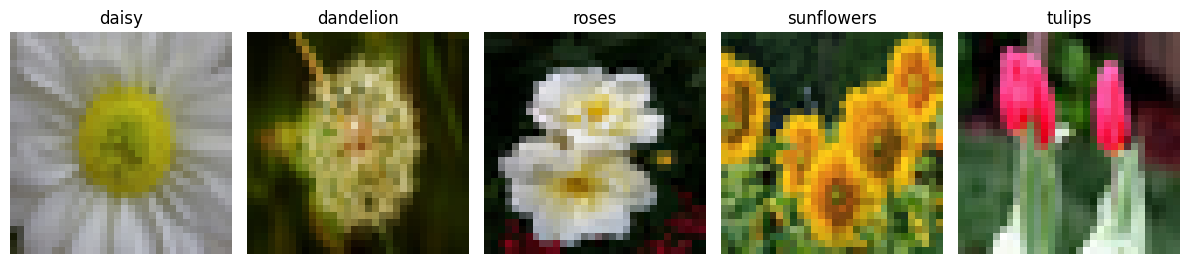

In [4]:
plt.figure(figsize=(12, 3))

for i, class_name in enumerate(class_names):
    index = np.where(labels == class_name)[0][0]
    # Title & label
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[index])
    plt.title(class_name)
    plt.axis("off")
plt.tight_layout()
plt.show()

**- Flatten the images and split the dataset**

In [5]:
X = images.reshape(len(images), -1)
y = labels

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training features: (2936, 3072)
Testing features: (734, 3072)
Training labels: (2936,)
Testing labels: (734,)


## 2. Model Training

In [6]:
# Define the parameter grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}
# Create the Random Forest classifier
rf_model = RandomForestClassifier(random_state=42)

In [7]:
# Perform Grid Search and train the model
grid_search = GridSearchCV(
    estimator=rf_model, param_grid=param_grid, cv=3,
    scoring="accuracy", n_jobs=-1, verbose=2, refit=True
)
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 20], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy', verbose=2)

In [8]:
# Print the best parameters and retrieve the trained model
print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

best_rf_model = grid_search.best_estimator_

print("\nBest model:")
print(best_rf_model)

Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation accuracy: 0.5388

Best model:
RandomForestClassifier(max_depth=20, n_estimators=200, random_state=42)


## 3. Model Evaluation

**- Predictions, accuracy, precision, recall, and F1-score**

In [9]:
# Predictions
y_pred = best_rf_model.predict(X_test)

# ccuracy, precision, recall, and F1-score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.5354
Precision: 0.5376
Recall:    0.5354
F1-score:  0.5264


In [10]:
# Display the classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, labels=class_names, digits=4, zero_division=0))

Classification Report:

              precision    recall  f1-score   support

       daisy     0.5657    0.4409    0.4956       127
   dandelion     0.5289    0.7151    0.6081       179
       roses     0.5467    0.3203    0.4039       128
  sunflowers     0.6159    0.6643    0.6392       140
      tulips     0.4491    0.4688    0.4587       160

    accuracy                         0.5354       734
   macro avg     0.5412    0.5219    0.5211       734
weighted avg     0.5376    0.5354    0.5264       734



**- Create and visualize the confusion matrix**

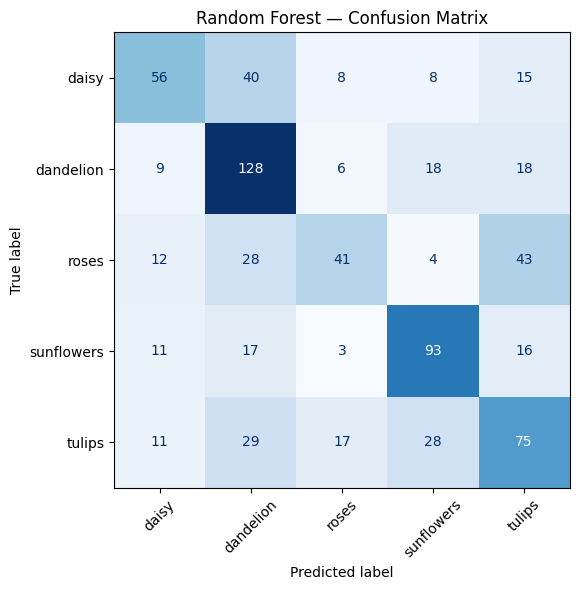

In [11]:
cm = confusion_matrix(y_test, y_pred, labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))

display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
display.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

# Title & label
ax.set_title("Random Forest — Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Feature Importance Visualization

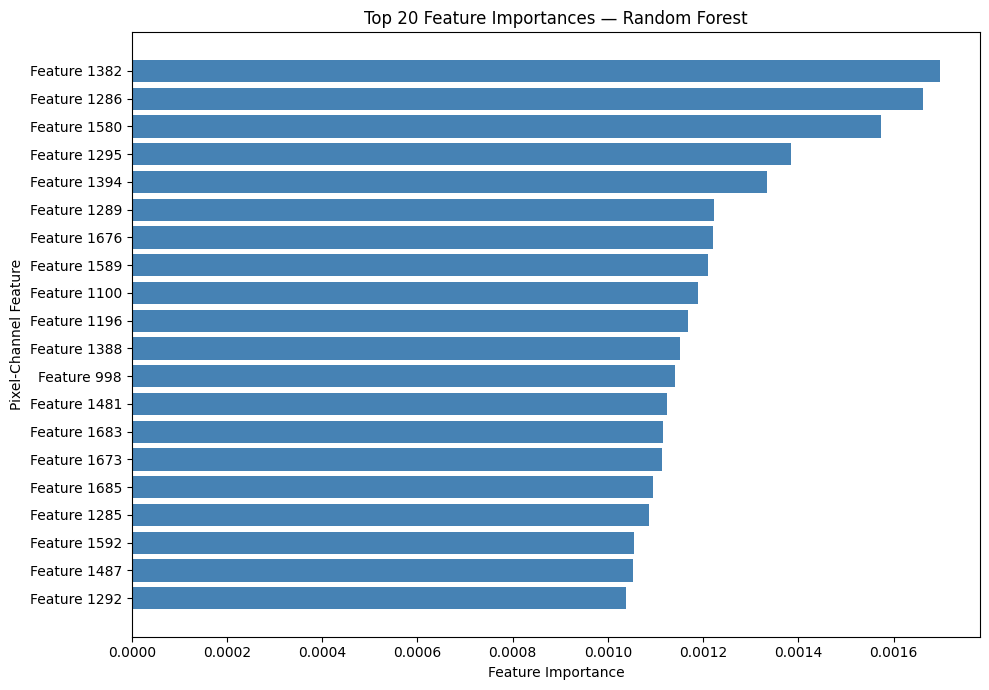

In [12]:
# Get the feature importances
feature_importances = best_rf_model.feature_importances_

# Plot the top 20 features
top_indices = np.argsort(feature_importances)[-20:]

plt.figure(figsize=(10, 7))

plt.barh([f"Feature {i}" for i in top_indices], feature_importances[top_indices], color="steelblue")
# Title & labels
plt.xlabel("Feature Importance")
plt.ylabel("Pixel-Channel Feature")
plt.title("Top 20 Feature Importances — Random Forest")
plt.tight_layout()
plt.show()

## 5. Prediction on New Images

In [13]:
# Prediction function
def predict_image(image_path):
    with Image.open(image_path) as img:
        img = img.convert("RGB")
        img = img.resize((32, 32), Image.Resampling.LANCZOS)
        img_array = np.asarray(img, dtype=np.float32) / 255.0
    image_features = img_array.reshape(1, -1)
    prediction = best_rf_model.predict(image_features)
    return prediction[0]

# New flower image in Google Colab uploaded
uploaded = files.upload()

Saving images.jpeg to images.jpeg


Image: images.jpeg
Predicted class: tulips


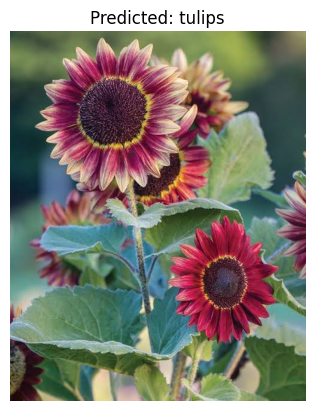

In [14]:
# Predict and display the image
for image_path in uploaded:
    predicted_class = predict_image(image_path)

    print(f"Image: {image_path}")
    print(f"Predicted class: {predicted_class}")

    with Image.open(image_path) as img:
        plt.imshow(img.convert("RGB"))
        plt.title(f"Predicted: {predicted_class}")
        plt.axis("off")
        plt.show()

## 6. Bonus: Comparing with SVM

In [17]:
# Define the SVM parameter grid
svm_param_grid = [
    {
        "kernel": ["linear"],
        "C": [0.1, 1, 10]
    },
    {
        "kernel": ["rbf"],
        "C": [0.1, 1, 10],
        "gamma": ["scale", "auto"]
    }
]

In [18]:
# Find the best parameters and train SVM
svm_grid_search = GridSearchCV(
    estimator=SVC(), param_grid=svm_param_grid, cv=3,  scoring="accuracy", n_jobs=-1, verbose=2, refit=True
)
svm_grid_search.fit(X_train, y_train)

print("Best parameters:", svm_grid_search.best_params_)
print(f"Best cross-validation accuracy: " f"{svm_grid_search.best_score_:.4f}")

best_svm_model = svm_grid_search.best_estimator_

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation accuracy: 0.5429


In [19]:
# Make predictions and display the classification report
svm_y_pred = best_svm_model.predict(X_test)

print("SVM Classification Report:\n")
print(classification_report(y_test, svm_y_pred, labels=class_names, digits=4, zero_division=0))

SVM Classification Report:

              precision    recall  f1-score   support

       daisy     0.5152    0.5354    0.5251       127
   dandelion     0.5640    0.6648    0.6103       179
       roses     0.5248    0.4141    0.4629       128
  sunflowers     0.6861    0.6714    0.6787       140
      tulips     0.4902    0.4688    0.4792       160

    accuracy                         0.5572       734
   macro avg     0.5560    0.5509    0.5512       734
weighted avg     0.5559    0.5572    0.5543       734



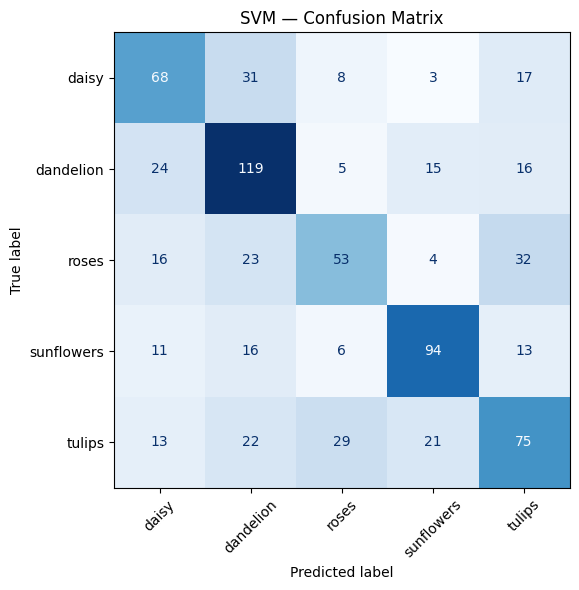

In [20]:
# Visualize the SVM confusion matrix
svm_cm = confusion_matrix(y_test, svm_y_pred, labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))

display = ConfusionMatrixDisplay(confusion_matrix=svm_cm, display_labels=class_names)
display.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
# Title & labels
ax.set_title("SVM — Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
# Compare Random Forest and SVM
rf_y_pred = best_rf_model.predict(X_test)

results = []

for model_name, predictions in [("Random Forest", rf_y_pred), ("SVM", svm_y_pred)]:
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, average="weighted", zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, average="weighted", zero_division=0
        ),
        "F1-score": f1_score(
            y_test, predictions, average="weighted", zero_division=0
        )
    })
comparison = pd.DataFrame(results).set_index("Model")

display(comparison.round(4))

,Accuracy,Precision,Recall,F1-score
Model,,,,
Random Forest,0.5354,0.5376,0.5354,0.5264
SVM,0.5572,0.5559,0.5572,0.5543


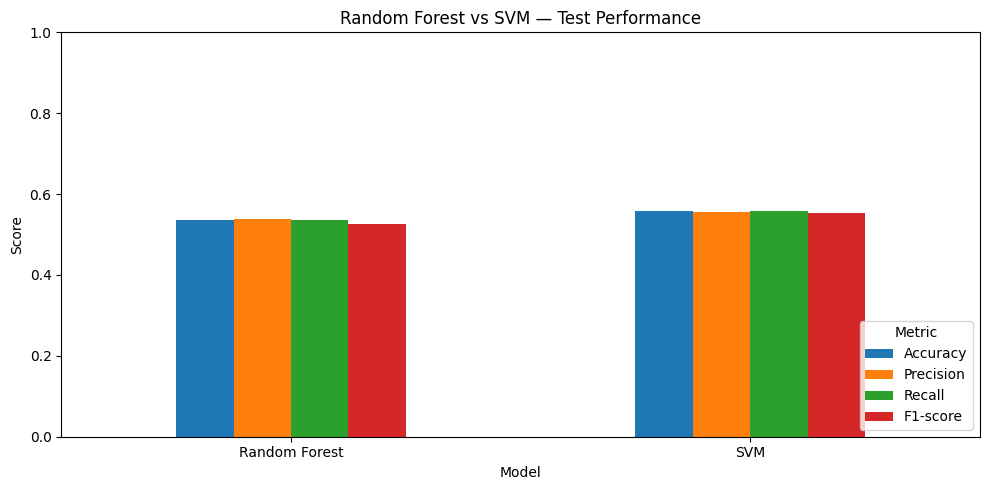

In [24]:
# Plot the comparison
comparison.plot(kind="bar", figsize=(10, 5), rot=0)
# Tilte & labels
plt.title("Random Forest vs SVM — Test Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Metric", loc="lower right")
plt.tight_layout()
plt.show()

In [1]:
!find "/content/drive/MyDrive" -iname "Assignment_11.ipynb"

find: ‘/content/drive/MyDrive’: No such file or directory


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls -la /content/colab-git-assignment2-ST

ls: cannot access '/content/colab-git-assignment2-ST': No such file or directory


In [4]:
!git clone https://github.com/StephaneTF/colab-git-assignment2-ST.git /content/colab-git-assignment2-ST

Cloning into '/content/colab-git-assignment2-ST'...
remote: Enumerating objects: 93, done.
remote: Counting objects: 100% (93/93), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 93 (delta 33), reused 36 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (93/93), 3.52 MiB | 10.45 MiB/s, done.
Resolving deltas: 100% (33/33), done.


In [5]:
!ls -la /content/colab-git-assignment2-ST

total 3796
drwxr-xr-x 9 root root    4096 Sep 19 09:48  .
drwxr-xr-x 1 root root    4096 Sep 19 09:48  ..
drwxr-xr-x 2 root root    4096 Sep 19 09:48  Assignment_12
drwxr-xr-x 2 root root    4096 Sep 19 09:48  Assignment_13
drwxr-xr-x 2 root root    4096 Sep 19 09:48  Assignment_14
-rw-r--r-- 1 root root  490404 Sep 19 09:48  Assignment_15.ipynb
-rw-r--r-- 1 root root    5415 Sep 19 09:48  assignment2.ipynb
drwxr-xr-x 2 root root    4096 Sep 19 09:48  Assignment_8
drwxr-xr-x 2 root root    4096 Sep 19 09:48  Assignment_9
drwxr-xr-x 8 root root    4096 Sep 19 09:48  .git
drwxr-xr-x 2 root root    4096 Sep 19 09:48  Lesson_10_assignment
-rw-r--r-- 1 root root   12704 Sep 19 09:48  Lesson_3_assignment.ipynb
-rw-r--r-- 1 root root   80271 Sep 19 09:48 'Lesson 4 assignment.ipynb'
-rw-r--r-- 1 root root  549515 Sep 19 09:48  Lesson_5_Assignment.ipynb
-rw-r--r-- 1 root root 2321005 Sep 19 09:48  Lesson_6_ml_basic_assignment.ipynb
-rw-r--r-- 1 root root  376413 Sep 19 09:48  Lesson_7_assignmen